In [1]:
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import pandas as pd

In [2]:
path = '../data/raw/spx_dividend_hist.xlsx'
spx_dividend = pd.read_excel(path)
print(spx_dividend)

      Unnamed: 0.1 Unnamed: 0  IN069 / DV105    IN060
0                0 2016-01-01         2.1806  44.5710
1                1 2016-01-04         2.2148  44.5761
2                2 2016-01-05         2.2106  44.5815
3                3 2016-01-06         2.2401  44.5846
4                4 2016-01-07         2.2943  44.5801
...            ...        ...            ...      ...
2676          2676 2026-04-06         1.2805  84.6657
2677          2677 2026-04-07         1.2792  84.6454
2678          2678 2026-04-08         1.2475  84.6181
2679          2679 2026-04-09         1.2394  84.5843
2680          2680 2026-04-10         1.2394  84.5843

[2681 rows x 4 columns]


In [3]:
spx_price = pd.read_excel('../data/processed/spx_close.xlsx')
spx_price['Date'] = pd.to_datetime(spx_price['Date'])
spx_price = spx_price.set_index('Date')
print(spx_price)

                   ^SPX
Date                   
2016-04-08  2047.599976
2016-04-11  2041.989990
2016-04-12  2061.719971
2016-04-13  2082.419922
2016-04-14  2082.780029
...                 ...
2026-03-31  6528.520020
2026-04-01  6575.319824
2026-04-02  6582.689941
2026-04-06  6611.830078
2026-04-07  6616.850098

[2513 rows x 1 columns]


In [4]:
rename_map = {
    'Unnamed: 0': 'Date',
    'IN069 / DV105': 'Est Dividends Yield',
    'IN060': 'Est Dividends',
}

spx_dividend = spx_dividend.rename(columns=rename_map)
spx_dividend = spx_dividend.drop(columns='Unnamed: 0.1')

spx_dividend['Date'] = pd.to_datetime(spx_dividend['Date'])
spx_dividend = spx_dividend.set_index('Date')
spx_dividend

,Est Dividends Yield,Est Dividends
Date,,
2016-01-01,2.1806,44.5710
2016-01-04,2.2148,44.5761
2016-01-05,2.2106,44.5815
2016-01-06,2.2401,44.5846
2016-01-07,2.2943,44.5801
...,...,...
2026-04-06,1.2805,84.6657
2026-04-07,1.2792,84.6454
2026-04-08,1.2475,84.6181


In [5]:
SPXDIVAN = pd.read_excel(path, sheet_name='SPXDIVAN')
SPXDIVAN = SPXDIVAN.rename(columns={'Unnamed: 0': 'Date'})
SPXDIVAN['Date'] = pd.to_datetime(SPXDIVAN['Date'])
SPXDIVAN = SPXDIVAN.drop(columns='Unnamed: 0.1')
SPXDIVAN = SPXDIVAN.set_index('Date')
SPXDIVAN

,SPXDIVAN
Date,
2016-01-04,1.708
2016-01-05,1.708
2016-01-06,2.423
2016-01-07,2.476
2016-01-08,2.482
...,...
2026-04-02,23.750
2026-04-06,24.250
2026-04-07,24.310


In [6]:
dividend_df = pd.concat([spx_dividend, SPXDIVAN, spx_price], axis=1, sort=False, join='inner')
dividend_df

,Est Dividends Yield,Est Dividends,SPXDIVAN,^SPX
Date,,,,
2016-04-08,2.2871,46.8301,13.599,2047.599976
2016-04-11,2.2928,46.8193,13.599,2041.989990
2016-04-12,2.2711,46.8233,13.664,2061.719971
2016-04-13,2.2487,46.8270,13.974,2082.419922
2016-04-14,2.2486,46.8324,14.182,2082.780029
...,...,...,...,...
2026-03-31,1.2977,84.7234,23.020,6528.520020
2026-04-01,1.2885,84.7234,23.270,6575.319824
2026-04-02,1.2870,84.7223,23.750,6582.689941


In [7]:
dividend_df.isna().sum()

Est Dividends Yield    0
Est Dividends          0
SPXDIVAN               0
^SPX                   0
dtype: int64

In [8]:
# dividend_df['Est Dividends Yield Cal'] = dividend_df['Est Dividends'] / dividend_df['^SPX']
# dividend_df['Est Dividends Yield Cal']
dividend_df['calc_yield'] = dividend_df['Est Dividends'] / dividend_df['^SPX']
dividend_df['Est Dividends Yield'] = dividend_df['Est Dividends Yield'] / 100
dividend_df['diff'] = dividend_df['Est Dividends Yield'] - dividend_df['calc_yield']

In [9]:
# Sanity Check: Est Dividend Yield
tol = 1e-4
count = (dividend_df['diff'].sum() > tol).sum()
count

0

In [10]:
dividend_df['remaining_div'] = (
    dividend_df['Est Dividends'] - dividend_df['SPXDIVAN']
)

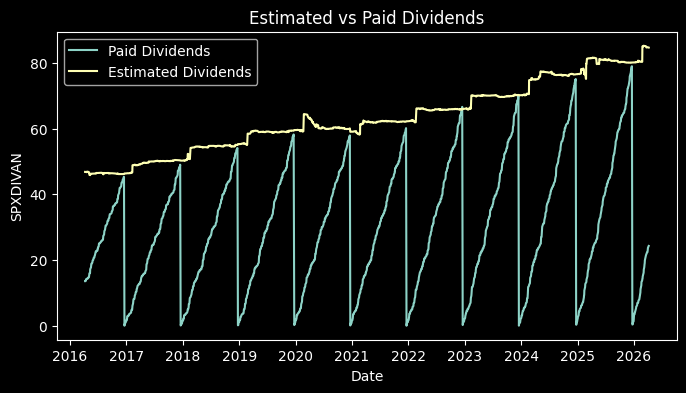

In [11]:
plt.figure(figsize=(8,4))

plt.plot(dividend_df.index, dividend_df['SPXDIVAN'], label='Paid Dividends')
plt.plot(dividend_df.index, dividend_df['Est Dividends'], label='Estimated Dividends')

plt.title('Estimated vs Paid Dividends')
plt.xlabel('Date')
plt.ylabel('SPXDIVAN')
plt.legend()
plt.show()


In [12]:
dividend_df['is_year_end'] = (dividend_df['SPXDIVAN'].diff() < 0).shift(-1).fillna(False)
dividend_df['is_year_end'].value_counts()

year_end_dates = dividend_df.index[dividend_df['is_year_end']]
next_year = year_end_dates[-1] + pd.Timedelta(days=365)
year_end_dates = year_end_dates.append(pd.DatetimeIndex([next_year]))
year_end_dates

DatetimeIndex(['2016-12-16', '2017-12-15', '2018-12-21', '2019-12-20',
               '2020-12-18', '2021-12-17', '2022-12-16', '2023-12-15',
               '2024-12-20', '2025-12-19', '2026-12-19'],
              dtype='datetime64[us]', freq=None)

In [13]:
dates = dividend_df.index
assigned_year_end =  []
i = 0
for date in dates:
    if i < len(year_end_dates) and date >= year_end_dates[i]:
        i += 1
    assigned_year_end.append(year_end_dates[i])

dividend_df['year_end'] = assigned_year_end
# dividend_df['year_end']
dividend_df

,Est Dividends Yield,Est Dividends,SPXDIVAN,^SPX,calc_yield,diff,remaining_div,is_year_end,year_end
Date,,,,,,,,,
2016-04-08,0.022871,46.8301,13.599,2047.599976,0.022871,2.730229e-07,33.2311,False,2016-12-16
2016-04-11,0.022928,46.8193,13.599,2041.989990,0.022928,-2.710610e-07,33.2203,False,2016-12-16
2016-04-12,0.022711,46.8233,13.664,2061.719971,0.022711,2.048070e-07,33.1593,False,2016-12-16
2016-04-13,0.022487,46.8270,13.974,2082.419922,0.022487,1.809353e-07,32.8530,False,2016-12-16
2016-04-14,0.022486,46.8324,14.182,2082.780029,0.022486,4.761611e-07,32.6504,False,2016-12-16
...,...,...,...,...,...,...,...,...,...
2026-03-31,0.012977,84.7234,23.020,6528.520020,0.012977,-4.282298e-07,61.7034,False,2026-12-19
2026-04-01,0.012885,84.7234,23.270,6575.319824,0.012885,-6.145175e-08,61.4534,False,2026-12-19
2026-04-02,0.012870,84.7223,23.750,6582.689941,0.012870,-4.679628e-07,60.9723,False,2026-12-19


In [14]:
dividend_df['T_remaining_days'] = (
    (dividend_df['year_end']  - dividend_df.index).dt.days
)

dividend_df['T_remaining'] = (
    dividend_df['T_remaining_days'] / 365
)

dividend_df['q'] = (dividend_df['remaining_div'] / dividend_df['^SPX']) / dividend_df['T_remaining']

dividend_df[['q', 'Est Dividends Yield']]

,q,Est Dividends Yield
Date,,
2016-04-08,0.023507,0.022871
2016-04-11,0.023848,0.022928
2016-04-12,0.023671,0.022711
2016-04-13,0.023313,0.022487
2016-04-14,0.023260,0.022486
...,...,...
2026-03-31,0.013117,0.012977
2026-04-01,0.013020,0.012885
2026-04-02,0.012953,0.012870


In [15]:
# pct = (dividend_df['q'] < dividend_df['Est Dividends Yield']).mean() * 100
# print(f'{pct}%')
# print('The estimated dividend yield should be lower after accounting for dividends already paid.')

In [16]:
dividend_df['Continuous Compounding Dividends Yield'] = np.log(1 + dividend_df['Est Dividends Yield'])

In [17]:
dividend_df[['q', 'Continuous Compounding Dividends Yield']]

,q,Continuous Compounding Dividends Yield
Date,,
2016-04-08,0.023507,0.022613
2016-04-11,0.023848,0.022669
2016-04-12,0.023671,0.022457
2016-04-13,0.023313,0.022238
2016-04-14,0.023260,0.022237
...,...,...
2026-03-31,0.013117,0.012894
2026-04-01,0.013020,0.012803
2026-04-02,0.012953,0.012788


In [18]:
# dividend_df['Dividends Yield'] = dividend_df['q']
# dividend_df = dividend_df['Dividends Yield']
dividend_df.to_excel('../data/processed/spx_dividend.xlsx')

<Axes: xlabel='Date'>

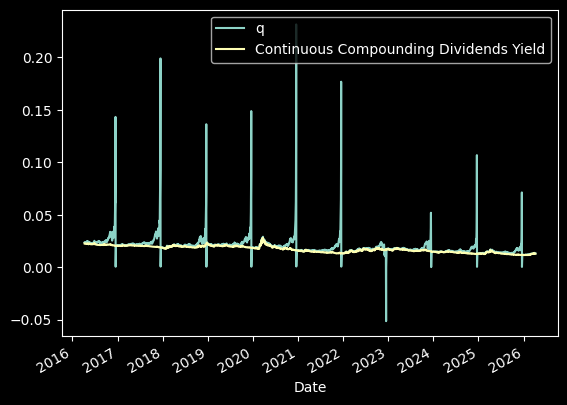

In [24]:
dividend_df[['q', 'Continuous Compounding Dividends Yield']].plot()

In [31]:
neg_div_dates = dividend_df['q'] < 0
neg_div_dates = neg_div_dates[neg_div_dates]
neg_div_dates

Date
2022-12-14    True
2022-12-15    True
2022-12-16    True
2023-12-15    True
Name: q, dtype: bool